In [109]:
#1
%matplotlib inline 
import torch
import numpy as np
import matplotlib.pyplot as plt
import helper_functions as hlp


torch.set_default_dtype(torch.float64)


T = 60e-6           
B = 2e6             
Fs = 5 * B          
N = int(np.round(T * Fs)) 

t_np = np.linspace(0, T, N, endpoint=False)
t = torch.tensor(t_np, dtype=torch.float64)

t_norm = t / torch.max(t)

b_slope = B/T
psi = 2 * np.pi * (b_slope/2) * t**2
a = 1
s_base = a * torch.complex(torch.cos(psi), torch.sin(psi))

null_freqs = [0.4e6] 
print(f"Targets defined at: {[f/1e6 for f in null_freqs]} MHz")

# Steering Matrix
steering_vectors = []
for f in null_freqs:
    w = 2 * np.pi * f
    vec = torch.complex(torch.cos(w * t), -torch.sin(w * t))
    steering_vectors.append(vec)

steering_matrix = torch.stack(steering_vectors)


z = torch.tensor(hlp.build_z(a,psi,t,null_freqs))
print(torch._shape_as_tensor(z))

Targets defined at: [0.4] MHz
tensor([600,   1])


In [111]:
from version1 import getphi 
phi_start =  getphi()

In [145]:
# יצירת וקטור רנדומלי בטווח [15 ,15-]
phi_start = (30 * torch.rand(600, dtype=torch.float64) - 15).detach().requires_grad_(True)

In [146]:
# 2
import copy 


phi = phi_start #torch.zeros(N, requires_grad=True, dtype=torch.float64)


learning_rate =  0.0055374071755859185
iterations = 10000 
beta_smooth = 2.6721252174776165e-05
beta_norm = 1.0365352004763621e-07
beta_div1 = 0.005072223833806753
beta_div2 = 2.926961237111151e-05

optimizer = torch.optim.Adam([phi], lr=learning_rate)

print(f"Starting Multi-Null Optimization ({iterations} iterations)...")
print(f"Saving best model based on Minimum Total Loss (Energy + Regularization)")

loss_history = []


best_loss = float('inf') 
best_phi = None
best_epoch = 0

for i in range(iterations):
    
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_transmit = s_base * correction_phasor
    
   
    spectral_vals = torch.matmul(steering_matrix, s_transmit)
    energies = torch.abs(spectral_vals)**2
    
     
    loss_nulls = torch.sum(energies) 
    
    #diff_phi = phi[1:] - phi[:-1]
    #reg_term = beta_smooth * torch.sum(diff_phi**2)
    
    
    loss_norm = beta_norm * torch.sum(phi**2)

    
    integrals1 = [
        torch.trapezoid(z[:, k] * correction_phasor * t_norm, x=t_norm) 
        for k in range(z.shape[1])
    ]
    
    loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])

    
    integrals2 = [
        torch.trapezoid(z[:, k] * correction_phasor * (t_norm**2), x=t_norm) 
        for k in range(z.shape[1])
    ]
    loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])
    loss = loss_nulls  + loss_norm  # + reg_term
    
    
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_phi = phi.clone() 
        best_epoch = i
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    
    if i % 1000 == 0:
        print(f"Iter {i}: Total Loss = {loss.item():.6f}")
       
        max_depth = 10 * np.log10(torch.max(energies).item() + 1e-40)
        print(f"   Worst Null Depth: {max_depth:.2f} dB")

print("\n--- Optimization Finished ---")
print(f"Restoring best model from Epoch {best_epoch} (Total Loss: {best_loss:.6f})")


with torch.no_grad():
    phi.copy_(best_phi)



final_spectral = torch.matmul(steering_matrix, s_base * torch.complex(torch.cos(phi), torch.sin(phi)))
final_energies = torch.abs(final_spectral)**2
print("Null Depths in Selected Model:")
for k, f in enumerate(null_freqs):
    e_db = 10 * np.log10(final_energies[k].item() + 1e-40)
    print(f"Freq {f/1e6} MHz: {e_db:.2f} dB")

Starting Multi-Null Optimization (10000 iterations)...
Saving best model based on Minimum Total Loss (Energy + Regularization)
Iter 0: Total Loss = 1859.774964
   Worst Null Depth: 32.69 dB
Iter 1000: Total Loss = 0.004425
   Worst Null Depth: -139.69 dB
Iter 2000: Total Loss = 0.004425
   Worst Null Depth: -139.69 dB
Iter 3000: Total Loss = 0.004425
   Worst Null Depth: -139.67 dB
Iter 4000: Total Loss = 0.004425
   Worst Null Depth: -139.64 dB
Iter 5000: Total Loss = 0.004425
   Worst Null Depth: -139.60 dB
Iter 6000: Total Loss = 0.004425
   Worst Null Depth: -86.95 dB
Iter 7000: Total Loss = 0.004425
   Worst Null Depth: -87.97 dB
Iter 8000: Total Loss = 0.004885
   Worst Null Depth: -33.37 dB
Iter 9000: Total Loss = 0.004626
   Worst Null Depth: -36.96 dB

--- Optimization Finished ---
Restoring best model from Epoch 9978 (Total Loss: 0.004425)
Null Depths in Selected Model:
Freq 0.4 MHz: -91.69 dB


--- True Null Depths (Calculated Mathematically) ---
Freq 0.4 MHz: -173.75 dB


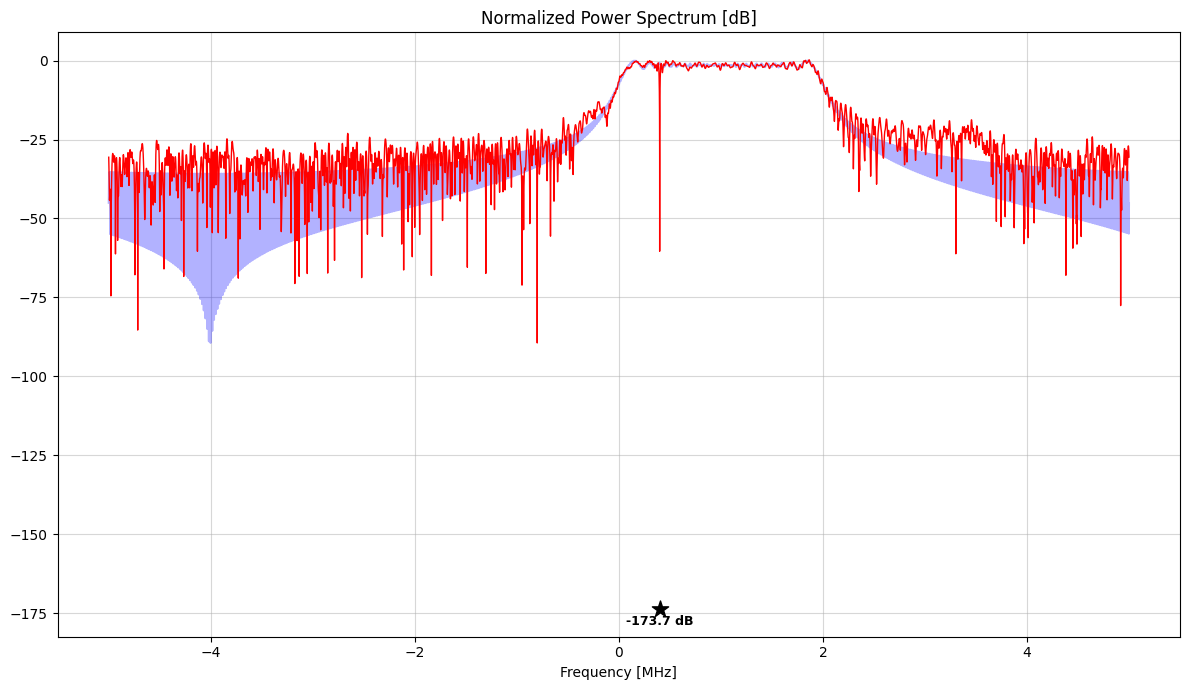

In [129]:
#3
null_freqs_np = np.array(null_freqs) 


with torch.no_grad():
    correction_phasor = torch.complex(torch.cos(best_phi), torch.sin(best_phi))
    s_transmit_best = s_base * correction_phasor
    
    phi_learned = best_phi.detach().cpu().numpy()
    s_final_np = s_transmit_best.detach().cpu().numpy()


N_fft = 2**18
freqs = np.fft.fftshift(np.fft.fftfreq(N_fft, 1/Fs))


S_orig = np.fft.fftshift(np.fft.fft(s_base.numpy(), n=N_fft))
S_final = np.fft.fftshift(np.fft.fft(s_final_np, n=N_fft))


S_orig_db = 20*np.log10(np.abs(S_orig) + 1e-15)
S_final_db = 20*np.log10(np.abs(S_final) + 1e-15)


peak_ref = np.max(S_orig_db)
S_orig_norm = S_orig_db - peak_ref
S_final_norm = S_final_db - peak_ref


with torch.no_grad():
    # חישוב ב-PyTorch
    exact_vals = torch.matmul(steering_matrix, s_transmit_best)
    energies_torch = torch.abs(exact_vals)**2
    
    # המרה מסודרת ל-Numpy
    energies_np = energies_torch.detach().cpu().numpy()
    
    # חישוב dB ב-Numpy
    exact_db_absolute = 10 * np.log10(energies_np + 1e-40)
    
    # נרמול
    exact_db_relative = exact_db_absolute - peak_ref

print("--- True Null Depths (Calculated Mathematically) ---")
for k, f_val in enumerate(null_freqs_np):
    print(f"Freq {f_val/1e6} MHz: {exact_db_relative[k]:.2f} dB")


# 5. הציור
plt.figure(figsize=(12, 7))

# גרף האות המקורי
plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue', alpha=0.3)

# גרף האות האופטימלי (FFT)
plt.plot(freqs/1e6, S_final_norm, label='Optimized Signal', color='red', linewidth=1)

# הוספת הכוכבים

plt.scatter(null_freqs_np/1e6, exact_db_relative, 
            color='black', marker='*', s=150, zorder=10, 
            label='Exact Analytical Depth')

# הוספת טקסט ליד הכוכבים
for k, f_val in enumerate(null_freqs_np):
    depth = exact_db_relative[k]
    plt.text(f_val/1e6, depth - 5, f"{depth:.1f} dB", 
             color='black', fontweight='bold', ha='center', fontsize=9)

plt.title("Normalized Power Spectrum [dB]")
plt.xlabel("Frequency [MHz]")

#plt.legend(loc='upper right')
plt.grid(True, alpha=0.5)
#plt.xlim(0, B/1e6 + 0.2)
#plt.ylim(-150, 5)
plt.tight_layout()
plt.show()

--- Matched Filter Performance ---
Selected Model based on Minimum Total Loss
Original LFM PSLR:  -42.10 dB
Optimized LFM PSLR: -33.72 dB
Degradation:        -8.39 dB


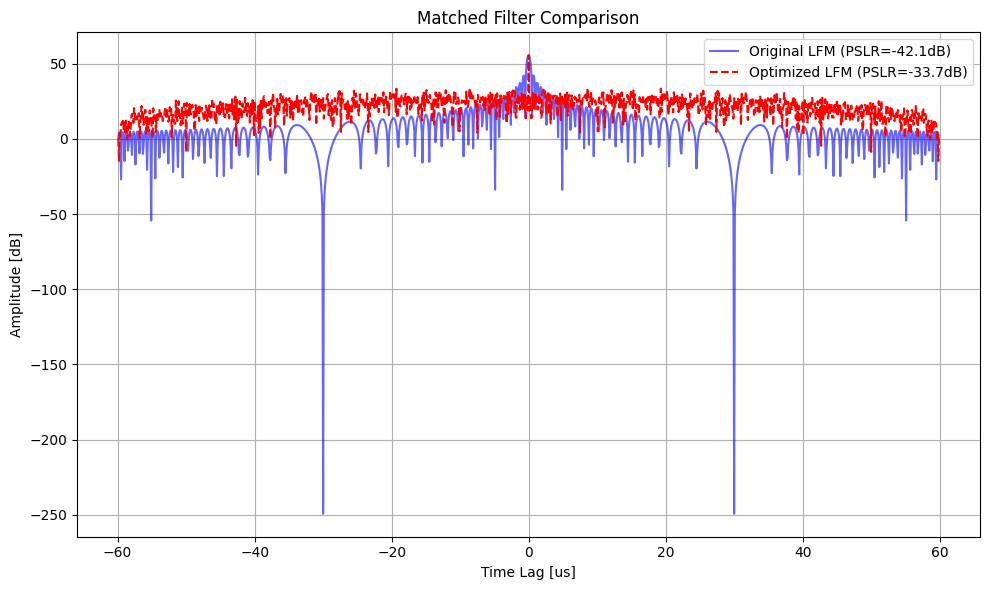

In [143]:
#4
with torch.no_grad():
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_best_time_domain = s_base * correction_phasor
    s_best_np = s_best_time_domain.detach().numpy()
    s_base_np = s_base.numpy()

def calculate_mf_and_pslr(signal):
    
    matched_filter = np.conj(signal[::-1])
    
    mf = np.convolve(signal, matched_filter, mode='full')
    
    mf_abs = np.abs(mf)
    mf_db = 20 * np.log10(mf_abs + 1e-20)
    
    center_idx = len(mf_db) // 2
    main_lobe_width_seconds = 2 / B
    margin_samples = int((main_lobe_width_seconds / 2) * Fs)
    
    left_side = mf_db[:center_idx - margin_samples]
    right_side = mf_db[center_idx + margin_samples:]
    
    sidelobe_region = np.concatenate((left_side, right_side))
    
    max_sidelobe = np.max(sidelobe_region)
    pslr = 0 - max_sidelobe
    return mf_db, pslr


mf_orig_db, pslr_orig = calculate_mf_and_pslr(s_base_np)
mf_new_db, pslr_new = calculate_mf_and_pslr(s_best_np)

print(f"--- Matched Filter Performance ---")
print(f"Selected Model based on Minimum Total Loss")
print(f"Original LFM PSLR:  {pslr_orig:.2f} dB")
print(f"Optimized LFM PSLR: {pslr_new:.2f} dB")
print(f"Degradation:        {pslr_orig - pslr_new:.2f} dB")


lags = np.arange(-len(s_base_np) + 1, len(s_base_np))
time_lags = (lags / Fs) * 1e6 

plt.figure(figsize=(10, 6))
plt.plot(time_lags, mf_orig_db, label=f'Original LFM (PSLR={pslr_orig:.1f}dB)', color='blue', alpha=0.6)
plt.plot(time_lags, mf_new_db, label=f'Optimized LFM (PSLR={pslr_new:.1f}dB)', color='red', linestyle='--')

plt.title("Matched Filter Comparison")
plt.xlabel("Time Lag [us]")
plt.ylabel("Amplitude [dB]")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [147]:
#5
phi_numpy = best_phi.detach().cpu().numpy()


correction_phasor = np.exp(1j * phi_numpy)


filename = 'optimal_phasor.npy'
np.save(filename, correction_phasor)

print(f"Success! Saved optimized phasor to '{filename}'")
print(f"File shape: {correction_phasor.shape}")

Success! Saved optimized phasor to 'optimal_phasor.npy'
File shape: (600,)


In [6]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [102]:
import torch
import numpy as np
import optuna

def objective(trial):
    
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    #b_smooth = trial.suggest_float("beta_smooth", 1e-5, 1.0, log=True)
    b_norm = trial.suggest_float("beta_norm", 1e-5, 1.0, log=True)
    beta_div1 = trial.suggest_float("beta_div1", 1e-5, 1.0, log=True)
    beta_div2 = trial.suggest_float("beta_div2", 1e-5, 1.0, log=True)
    
    phi = torch.zeros(N, requires_grad=True, dtype=torch.float64)
    optimizer = torch.optim.Adam([phi], lr=lr)
    
    best_loss = float('inf')
    iterations = 5000 

    
    for i in range(iterations):
        correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
        s_transmit = s_base * correction_phasor
        
        spectral_vals = torch.matmul(steering_matrix, s_transmit)
        energies = torch.abs(spectral_vals)**2
        
        loss_nulls = torch.sum(energies) 
        #diff_phi = phi[1:] - phi[:-1]
        #reg_term = b_smooth * torch.sum(diff_phi**2)
        loss_norm = b_norm * torch.sum(phi**2)   
        integrals1 = [
            torch.trapezoid(z[:, k] * correction_phasor * t_norm, x=t_norm) 
            for k in range(z.shape[1])
        ]
    
        loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])

    
        integrals2 = [
            torch.trapezoid(z[:, k] * correction_phasor * (t_norm**2), x=t_norm) 
            for k in range(z.shape[1])
        ]
        loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])
        loss = loss_nulls  + loss_norm + loss_div1 + loss_div2 # + reg_term
        
        
        if loss.item() < best_loss:
            best_loss = loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return best_loss


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30) 

print("Best Parameters found:", study.best_params)

[I 2026-02-22 15:28:50,859] A new study created in memory with name: no-name-c1dde950-0b98-4b3f-a7ff-cdeba7428811
[I 2026-02-22 15:29:12,564] Trial 0 finished with value: 31.786930958366703 and parameters: {'lr': 0.00408339809936544, 'beta_norm': 0.7851808973783597, 'beta_div1': 0.000668189885337189, 'beta_div2': 0.00033469615391584914}. Best is trial 0 with value: 31.786930958366703.
[I 2026-02-22 15:29:34,034] Trial 1 finished with value: 0.03810720014434203 and parameters: {'lr': 0.0070598674407564505, 'beta_norm': 0.0006808389922247472, 'beta_div1': 0.03027304797285899, 'beta_div2': 0.002136722055461361}. Best is trial 1 with value: 0.03810720014434203.
[I 2026-02-22 15:29:55,603] Trial 2 finished with value: 16.723916688054267 and parameters: {'lr': 0.01258965738896377, 'beta_norm': 0.4125234583408738, 'beta_div1': 0.12255759193906254, 'beta_div2': 0.10784926666060465}. Best is trial 1 with value: 0.03810720014434203.
[I 2026-02-22 15:30:16,924] Trial 3 finished with value: 9.9879

Best Parameters found: {'lr': 0.0055374071755859185, 'beta_norm': 1.0365352004763621e-05, 'beta_div1': 0.005072223833806753, 'beta_div2': 2.926961237111151e-05}


In [107]:
#5 - ISLR Calculation
def calculate_islr(signal):
    matched_filter = np.conj(signal[::-1])
    mf = np.convolve(signal, matched_filter, mode='full')
    mf_abs = np.abs(mf)

    center_idx = len(mf_abs) // 2
    main_lobe_width_seconds = 2 / B
    margin_samples = int((main_lobe_width_seconds / 2) * Fs)

    # Main lobe energy
    main_lobe = mf_abs[center_idx - margin_samples : center_idx + margin_samples]
    main_lobe_energy = np.sum(main_lobe ** 2)

    # Sidelobe energy (everything outside the main lobe)
    left_side  = mf_abs[:center_idx - margin_samples]
    right_side = mf_abs[center_idx + margin_samples:]
    sidelobe_energy = np.sum(left_side ** 2) + np.sum(right_side ** 2)

    islr = 10 * np.log10(sidelobe_energy / main_lobe_energy)
    return islr


islr_orig = calculate_islr(s_base_np)
islr_new  = calculate_islr(s_best_np)

print(f"--- ISLR Performance ---")
print(f"Original LFM ISLR:  {islr_orig:.2f} dB")
print(f"Optimized LFM ISLR: {islr_new:.2f} dB")
print(f"Degradation:        {islr_orig - islr_new:.2f} dB") # needs to be positive 

--- ISLR Performance ---
Original LFM ISLR:  -9.76 dB
Optimized LFM ISLR: -6.67 dB
Degradation:        -3.08 dB
